In [31]:
import json
import csv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict
import os


In [32]:
DATA_DIR   = "./data"
MODELS_DIR = "./models"
GENRE_EMBEDDINGS_PATH = f"{DATA_DIR}/embeddings/genre_embeddings.json"
TAG_EMBEDDINGS_PATH   = f"{DATA_DIR}/embeddings/tag_embeddings.json"
SONGS_CSV             = f"{DATA_DIR}/csv/songs.csv"
TAGS_CSV              = f"{DATA_DIR}/csv/tags.csv"


In [33]:
# ── Config ─────────────────────────────────────────────────────────────────────
EMBED_DIM  = 96       # 32 (genre) + 64 (tag)
HIDDEN_DIM = 128
LATENT_DIM = 16
EPOCHS     = 200
BATCH_SIZE = 256
LR         = 1e-3
BETA       = 0.005
PATIENCE   = 5
MIN_DELTA  = 0.0001


In [34]:
# ── Load embeddings + build per-song vectors ───────────────────────────────────
with open(GENRE_EMBEDDINGS_PATH) as f: genre_raw = json.load(f)
with open(TAG_EMBEDDINGS_PATH)   as f: tag_raw   = json.load(f)

g_idx = {g: i for i, g in enumerate(genre_raw)}
t_idx = {t: i for i, t in enumerate(tag_raw)}
G_arr = np.array(list(genre_raw.values()), dtype=np.float32)
T_arr = np.array(list(tag_raw.values()),   dtype=np.float32)
GENRE_DIM, TAG_DIM = G_arr.shape[1], T_arr.shape[1]

def read_csv(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=';')
        headers = [h.strip().strip('"') for h in next(reader)[0].split(',')]
        return [dict(zip(headers, [p.strip().strip('"') for p in row]))
                for row in reader if len(row) == len(headers)]

song_lookup = {}
song_genres = defaultdict(set)
for row in read_csv(SONGS_CSV):
    sid = row['spotify_id']
    song_lookup[sid] = row
    if row['genre_name'] in g_idx:
        song_genres[sid].add(row['genre_name'])

song_tags_full = defaultdict(dict)
for row in read_csv(TAGS_CSV):
    sid, tag = row['song_spotify_id'], row['tag'].lower().strip()
    pop = int(row['popularity']) if row['popularity'].isdigit() else 0
    if tag in t_idx and pop > song_tags_full[sid].get(tag, 0):
        song_tags_full[sid][tag] = pop
song_tags = {sid: sorted(d.items(), key=lambda x: -x[1])[:8]
             for sid, d in song_tags_full.items()}

def song_to_vec(sid):
    g_set = song_genres.get(sid, set())
    if not g_set: return None
    g_mean = np.mean([G_arr[g_idx[g]] for g in g_set], axis=0)
    tags = song_tags.get(sid, [])
    if tags: t_mean = np.mean([T_arr[t_idx[t]] for t, _ in tags], axis=0)
    else:    t_mean = np.zeros(TAG_DIM, dtype=np.float32)
    return np.concatenate([g_mean, t_mean]).astype(np.float32)

song_vectors, song_ids = [], []
for sid in song_genres:
    v = song_to_vec(sid)
    if v is not None:
        song_vectors.append(v)
        song_ids.append(sid)

X = torch.tensor(np.stack(song_vectors), dtype=torch.float32)
print(f"{X.shape[0]:,} songs | embed_dim={X.shape[1]}")

dataset    = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


177,079 songs | embed_dim=96


In [35]:
# ── VAE ────────────────────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, embed_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )
        self.mu_layer     = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-4, max=4)
        if self.training:
            return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, x, mu, logvar, beta=BETA):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl_loss    = torch.mean(torch.clamp(
        -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()), min=0.01
    ))
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [36]:
# ── Train (or load if model exists) ────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using: {device}")

os.makedirs(MODELS_DIR, exist_ok=True)
MODEL_PATH = f"{MODELS_DIR}/vae_model.pt"

model = VAE(EMBED_DIM, HIDDEN_DIM, LATENT_DIM).to(device)

RETRAIN = False   # set True to force retraining

if not RETRAIN and os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f"Loaded saved model from {MODEL_PATH}")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_loss, patience_counter = float('inf'), 0

    for epoch in range(EPOCHS):
        model.train()
        total_loss = total_recon = total_kl = 0.0

        for (batch,) in dataloader:
            batch             = batch.to(device)
            recon, mu, logvar = model(batch)
            loss, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()

        n        = len(dataloader)
        avg_loss = total_loss / n
        print(f"Epoch {epoch+1}/{EPOCHS} \u2014 loss={avg_loss:.4f} | recon={total_recon/n:.4f} | kl={total_kl/n:.4f}")

        if avg_loss < best_loss - MIN_DELTA:
            best_loss, patience_counter = avg_loss, 0
            torch.save(model.state_dict(), MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f"Best loss: {best_loss:.4f} \u2014 saved to {MODEL_PATH}")


Using: mps
Epoch 1/200 — loss=0.0085 | recon=0.0084 | kl=0.0228
Epoch 2/200 — loss=0.0081 | recon=0.0078 | kl=0.0586
Epoch 3/200 — loss=0.0079 | recon=0.0074 | kl=0.1069
Epoch 4/200 — loss=0.0077 | recon=0.0070 | kl=0.1434
Epoch 5/200 — loss=0.0076 | recon=0.0067 | kl=0.1675
Epoch 6/200 — loss=0.0075 | recon=0.0066 | kl=0.1747
Epoch 7/200 — loss=0.0075 | recon=0.0066 | kl=0.1799
Epoch 8/200 — loss=0.0075 | recon=0.0065 | kl=0.1853
Epoch 9/200 — loss=0.0074 | recon=0.0065 | kl=0.1883
Epoch 10/200 — loss=0.0074 | recon=0.0065 | kl=0.1913
Epoch 11/200 — loss=0.0074 | recon=0.0064 | kl=0.1939
Epoch 12/200 — loss=0.0074 | recon=0.0064 | kl=0.1956
Epoch 13/200 — loss=0.0074 | recon=0.0064 | kl=0.1973
Early stopping.
Best loss: 0.0075 — saved to ./models/vae_model.pt


In [37]:
# ── Extract latent vectors ─────────────────────────────────────────────────────
model.eval()

with torch.no_grad():
    mu, _ = model.encode(X.to(device))
    Z_all = mu.cpu().numpy()

print(f"Latent vectors: {Z_all.shape}")


Latent vectors: (177079, 16)


In [38]:
# ── Save song latent vectors ───────────────────────────────────────────────────
song_latents = {song_ids[i]: Z_all[i].tolist() for i in range(len(song_ids))}

with open(f"{DATA_DIR}/embeddings/song_latents.json", "w") as f:
    json.dump(song_latents, f)

print(f"Saved {len(song_latents):,} song latents.")


Saved 177,079 song latents.


In [39]:
# ── Setup for morph + visualisation ────────────────────────────────────────────
import math
import colorsys
from PIL import Image, ImageDraw, ImageFont
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

MORPH_FRAMES = 60
SIZE         = 400
FPS          = 20


In [40]:
# ── Renderer + synthesis (vector -> nearest genres/tags) ───────────────────────
COLOR_OVERRIDES = {
    "metal":[120,10,10],"death metal":[80,10,20],"black metal":[25,15,35],
    "thrash metal":[140,20,20],"doom metal":[50,20,40],"grindcore":[110,10,30],
    "hardcore":[160,20,20],"punk":[180,20,40],"grunge":[90,60,30],"emo":[70,30,60],
    "goth":[40,20,60],"industrial":[60,60,70],"darkwave":[50,30,80],
    "rap":[50,50,60],"hip hop":[70,60,90],"trap":[80,30,100],
    "folk":[140,180,70],"country":[200,140,60],"acoustic":[200,170,110],
    "blues":[40,80,180],"pop":[255,100,180],"dance pop":[255,80,200],
    "edm":[50,220,220],"house":[120,60,230],"tropical house":[255,200,80],
    "reggaeton":[255,80,60],"classical":[220,220,250],"ambient":[80,140,200],
    "chillout":[120,200,220],"jazz":[180,130,50],"soul":[180,80,40],
    "funk":[220,140,50],"r&b":[150,40,110],"rock":[180,60,60],
    "classic rock":[200,90,50],"shoegaze":[140,120,200],
    "melancholic":[60,80,140],"dark":[25,20,40],"happy":[255,220,80],
    "sad":[70,90,150],"chill":[120,200,220],"aggressive":[200,30,30],
    "energetic":[255,120,40],"romantic":[220,100,150],"atmospheric":[120,140,180],
    "upbeat":[255,180,80],"heavy":[50,40,50],"nostalgic":[180,140,100],
    "dreamy":[180,180,240],"epic":[80,50,130],
}
COLOR_OVERRIDES = {k: np.array(v, dtype=np.float32) for k, v in COLOR_OVERRIDES.items()}

G_norm = G_arr / (np.linalg.norm(G_arr, axis=1, keepdims=True) + 1e-9)
T_norm = T_arr / (np.linalg.norm(T_arr, axis=1, keepdims=True) + 1e-9)
pca_g_color  = PCA(n_components=3).fit(G_norm)
pca_t_color  = PCA(n_components=3).fit(T_norm)
pca_g_layout = PCA(n_components=2).fit(G_norm)
pca_t_layout = PCA(n_components=2).fit(T_norm)

genre_names = list(g_idx.keys())
tag_names   = list(t_idx.keys())

def vec_to_rgb(vec, pca, temp=3.0, hue_offset=0.15):
    p = np.tanh(pca.transform(vec.reshape(1, -1))[0] * temp)
    h = (np.arctan2(p[1], p[0]) / (2 * np.pi) + 0.5 + hue_offset) % 1.0
    s = np.clip(np.sqrt(p[0]**2 + p[1]**2) * 0.5 + 0.5, 0.5, 1.0)
    v = np.clip((p[2] + 1) / 2, 0.2, 1.0)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return np.array([r * 255, g * 255, b * 255], dtype=np.float32)

def vec_to_xy(vec, pca, size, padding=0.18):
    p   = pca.transform(vec.reshape(1, -1))[0]
    p_t = np.tanh(p * 0.6)
    x   = (p_t[0] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    y   = (p_t[1] + 1) / 2 * size * (1 - 2 * padding) + size * padding
    return float(x), float(y)

def get_genre_color(name):
    n = name.lower()
    if n in COLOR_OVERRIDES: return COLOR_OVERRIDES[n].copy()
    if n in g_idx:           return vec_to_rgb(G_norm[g_idx[n]], pca_g_color)
    return None

def get_tag_color(name):
    n = name.lower()
    if n in COLOR_OVERRIDES: return COLOR_OVERRIDES[n].copy()
    if n in t_idx:           return vec_to_rgb(T_norm[t_idx[n]], pca_t_color)
    return None

G_ref = G_norm.copy()
T_ref = T_norm.copy()

def synthesize(song_vec, top_g=5, top_t=8):
    g_part = song_vec[:GENRE_DIM]
    t_part = song_vec[GENRE_DIM:]
    g_n    = g_part / (np.linalg.norm(g_part) + 1e-9)
    t_n    = t_part / (np.linalg.norm(t_part) + 1e-9)
    g_sims = G_ref @ g_n
    t_sims = T_ref @ t_n
    g_top  = np.argsort(g_sims)[::-1][:top_g]
    t_top  = np.argsort(t_sims)[::-1][:top_t]
    return ([(genre_names[i], float(g_sims[i])) for i in g_top],
            [(tag_names[i],   float(t_sims[i])) for i in t_top])

def render_synthetic(song_vec, size=SIZE):
    syn_genres, syn_tags = synthesize(song_vec)
    canvas = np.zeros((size, size, 3), dtype=np.float32)
    y_grid, x_grid = np.mgrid[0:size, 0:size]

    n_g, n_t = len(syn_genres), len(syn_tags)
    genre_base = size * (0.20 + 0.10 / max(n_g, 1))
    tag_base   = size * (0.12 + 0.06 / max(n_t, 1))

    g_max = max((s for _, s in syn_genres), default=1)
    for name, sim in syn_genres:
        color = get_genre_color(name)
        if color is None: continue
        x, y = vec_to_xy(G_norm[g_idx[name]], pca_g_layout, size, padding=0.22)
        weight = max(sim / g_max, 0.3)
        radius = genre_base * weight
        dist = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
        mask = np.clip(1 - dist / radius, 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.04 * weight

    t_max = max((s for _, s in syn_tags), default=1)
    for name, sim in syn_tags:
        color = get_tag_color(name)
        if color is None: continue
        x, y = vec_to_xy(T_norm[t_idx[name]], pca_t_layout, size, padding=0.15)
        weight = max(sim / t_max, 0.3)
        radius = tag_base * weight
        dist = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
        mask = np.clip(1 - dist / radius, 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.04 * weight

    canvas = np.clip(canvas, 0, 1)
    mx = canvas.max(-1); mn = canvas.min(-1)
    L  = (mx + mn) / 2
    L_capped = np.minimum(L, 0.78)
    scale    = np.where(L > 0, L_capped / (L + 1e-9), 1.0)
    canvas   = canvas * scale[..., None]
    canvas   = np.power(canvas, 0.85)
    return (np.clip(canvas, 0, 1) * 255).astype(np.uint8), syn_genres, syn_tags


In [41]:
# ── Morph comparison: VAE latent path vs raw linear path ──────────────────────
SONG_A = "5kapVb34raTBsynt0Zj6qw"   # Bossa Antigua - Paul Desmond (jazz)
SONG_B = "1mD0LxzCdfathf6j7xMp7b"   # Player One - Machinae Supremacy (metal)

def encode_song(sid):
    if sid not in song_genres: raise ValueError(f"Unknown: {sid}")
    v = song_to_vec(sid)
    with torch.no_grad():
        mu, _ = model.encode(torch.tensor(v).unsqueeze(0).to(device))
    return v, mu.cpu().numpy()[0]

v_a, z_a = encode_song(SONG_A)
v_b, z_b = encode_song(SONG_B)

print(f"A: {song_lookup[SONG_A].get('name', SONG_A)} - {song_lookup[SONG_A].get('artist','')}")
print(f"B: {song_lookup[SONG_B].get('name', SONG_B)} - {song_lookup[SONG_B].get('artist','')}")

vae_frames, vae_genres, vae_tags = [], [], []
raw_frames, raw_genres, raw_tags = [], [], []

for f in range(MORPH_FRAMES):
    t = f / (MORPH_FRAMES - 1)

    # VAE path: interpolate in latent space, decode
    z_t = (1 - t) * z_a + t * z_b
    with torch.no_grad():
        v_vae = model.decode(torch.tensor(z_t).float().unsqueeze(0).to(device)).cpu().numpy()[0]
    img, sg, st = render_synthetic(v_vae)
    vae_frames.append(img); vae_genres.append(sg); vae_tags.append(st)

    # Raw path: linear in input vector space (no VAE)
    v_raw = (1 - t) * v_a + t * v_b
    img, sg, st = render_synthetic(v_raw)
    raw_frames.append(img); raw_genres.append(sg); raw_tags.append(st)

print("=" * 60)
for label, idx in [("START", 0), ("MIDDLE", MORPH_FRAMES // 2), ("END", MORPH_FRAMES - 1)]:
    print(f"\n[{label}]")
    print(f"  VAE: {[g for g, _ in vae_genres[idx][:4]]}")
    print(f"  RAW: {[g for g, _ in raw_genres[idx][:4]]}")
print("=" * 60)


A: Bossa Antigua - Paul Desmond
B: Player One - Machinae Supremacy

[START]
  VAE: ['cool jazz', 'contemporary post-bop', 'bebop', 'hard bop']
  RAW: ['cool jazz', 'bebop', 'jazz', 'hard bop']

[MIDDLE]
  VAE: ['ethiopian pop', 'roots reggae', 'traditional reggae', 'dancehall']
  RAW: ['neo classical metal', 'contemporary post-bop', 'cool jazz', 'danish jazz']

[END]
  VAE: ['death metal', 'groove metal', 'deathgrind', 'grindcore']
  RAW: ['melodic death metal', 'symphonic metal', 'power metal', 'gothic symphonic metal']


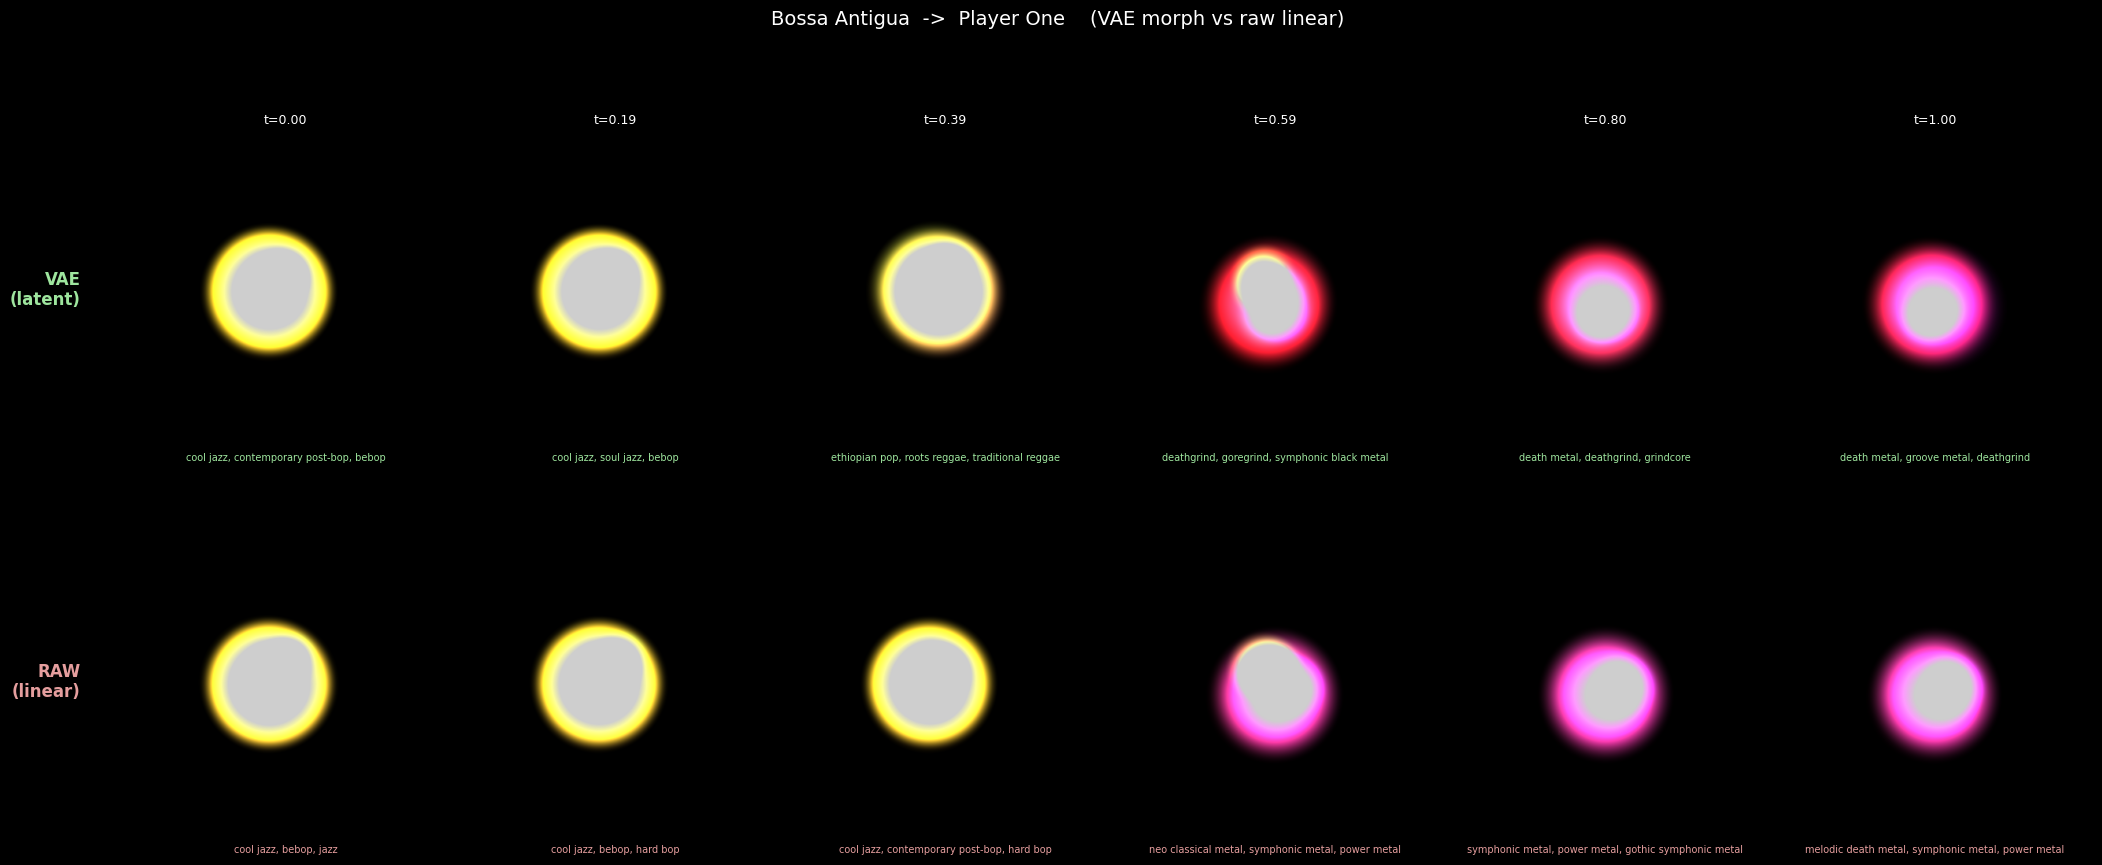

Saved: ./data/animations/morph_compare_Bossa_Antigua_to_Player_One.png


In [42]:
# ── Side-by-side comparison image ──────────────────────────────────────────────
os.makedirs(f"{DATA_DIR}/animations", exist_ok=True)

N_SHOW = 6
indices = np.linspace(0, MORPH_FRAMES - 1, N_SHOW).astype(int)

fig, axes = plt.subplots(2, N_SHOW, figsize=(3.5 * N_SHOW, 9))
fig.patch.set_facecolor('#000000')

for col, idx in enumerate(indices):
    for row, (frames_, genres_, label_color) in enumerate([
        (vae_frames, vae_genres, '#9ee59e'),
        (raw_frames, raw_genres, '#e59e9e'),
    ]):
        ax = axes[row, col]
        ax.imshow(frames_[idx])
        ax.set_facecolor('#000000')
        if row == 0: ax.set_title(f"t={idx/(MORPH_FRAMES-1):.2f}", color='white', fontsize=9)
        ax.set_xlabel(', '.join(g for g, _ in genres_[idx][:3]),
                      color=label_color, fontsize=7, labelpad=4)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)

axes[0, 0].text(-0.15, 0.5, 'VAE\n(latent)',  transform=axes[0, 0].transAxes,
                color='#9ee59e', fontsize=12, fontweight='bold', ha='right', va='center')
axes[1, 0].text(-0.15, 0.5, 'RAW\n(linear)',  transform=axes[1, 0].transAxes,
                color='#e59e9e', fontsize=12, fontweight='bold', ha='right', va='center')

a_name = song_lookup[SONG_A].get('name', SONG_A)
b_name = song_lookup[SONG_B].get('name', SONG_B)
plt.suptitle(f"{a_name}  ->  {b_name}    (VAE morph vs raw linear)",
             color='white', fontsize=14, y=1.01)
plt.tight_layout()

out = f"{DATA_DIR}/animations/morph_compare_{a_name[:15].replace(' ','_')}_to_{b_name[:15].replace(' ','_')}.png"
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print(f"Saved: {out}")


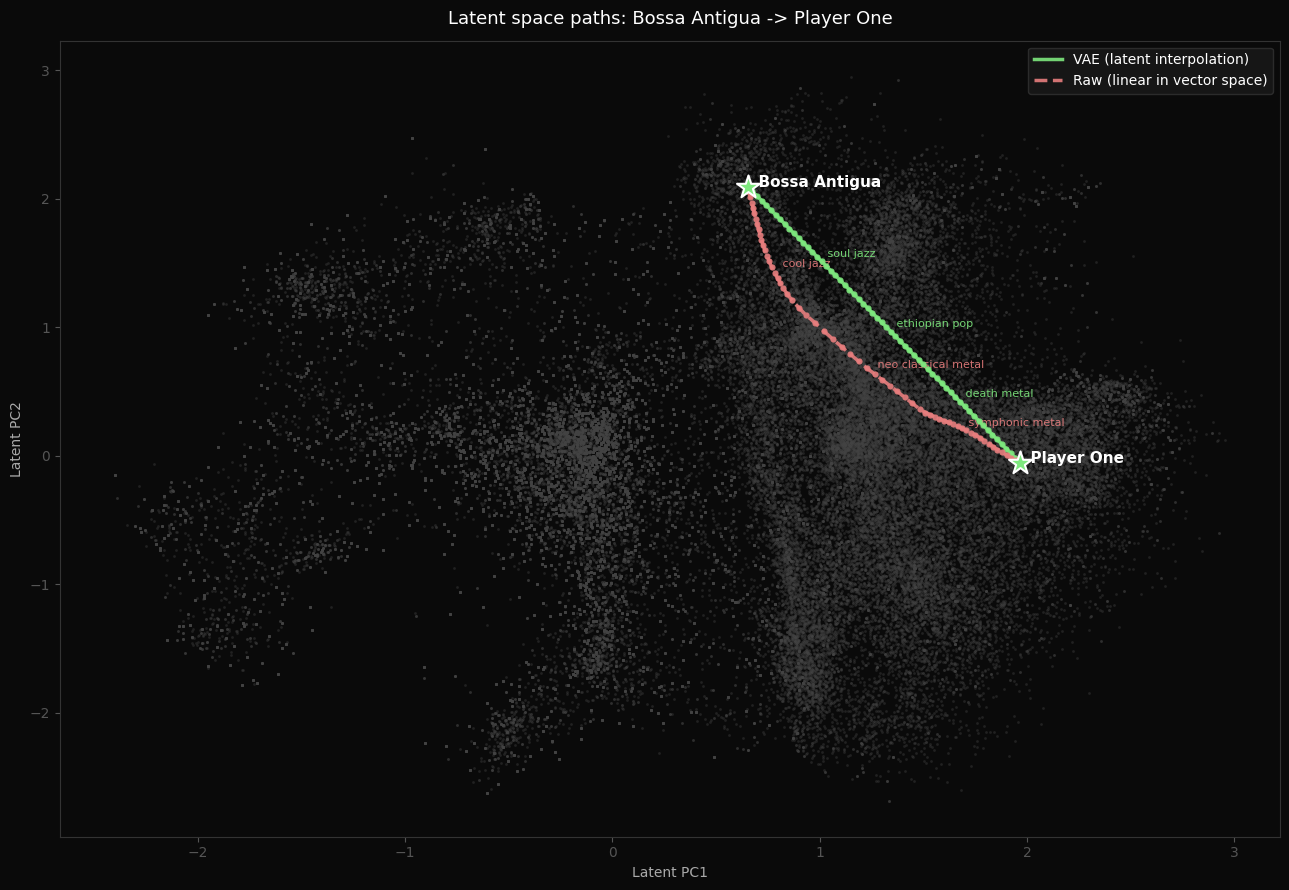

Saved: ./data/animations/latent_path_Bossa_Antigua_to_Player_One.png


In [43]:
# ── Visualise the path each method takes through latent space ──────────────────
pca_2d = PCA(n_components=2).fit(Z_all)
all_2d = pca_2d.transform(Z_all)

vae_latents = []
raw_latents = []
for f in range(MORPH_FRAMES):
    t = f / (MORPH_FRAMES - 1)
    vae_latents.append((1 - t) * z_a + t * z_b)
    v_raw = (1 - t) * v_a + t * v_b
    with torch.no_grad():
        mu, _ = model.encode(torch.tensor(v_raw).float().unsqueeze(0).to(device))
    raw_latents.append(mu.cpu().numpy()[0])

vae_2d = pca_2d.transform(np.stack(vae_latents))
raw_2d = pca_2d.transform(np.stack(raw_latents))

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')
ax.scatter(all_2d[:, 0], all_2d[:, 1], s=4, c='#444', alpha=0.4, linewidths=0)

ax.plot(vae_2d[:, 0], vae_2d[:, 1], color='#7ee87e', linewidth=2.5, alpha=0.9, label='VAE (latent interpolation)')
ax.scatter(vae_2d[:, 0], vae_2d[:, 1], s=20, c='#7ee87e', alpha=0.9, linewidths=0, zorder=5)
ax.plot(raw_2d[:, 0], raw_2d[:, 1], color='#e87e7e', linewidth=2.5, alpha=0.9, linestyle='--', label='Raw (linear in vector space)')
ax.scatter(raw_2d[:, 0], raw_2d[:, 1], s=20, c='#e87e7e', alpha=0.9, linewidths=0, zorder=5)

ax.scatter(*pca_2d.transform([z_a])[0], s=300, c='#7ee87e', marker='*', edgecolors='white', linewidths=1.5, zorder=10)
ax.scatter(*pca_2d.transform([z_b])[0], s=300, c='#7ee87e', marker='*', edgecolors='white', linewidths=1.5, zorder=10)
ax.annotate(f"  {song_lookup[SONG_A].get('name','A')}", pca_2d.transform([z_a])[0], color='white', fontsize=11, fontweight='bold')
ax.annotate(f"  {song_lookup[SONG_B].get('name','B')}", pca_2d.transform([z_b])[0], color='white', fontsize=11, fontweight='bold')

for label_idx in [MORPH_FRAMES // 4, MORPH_FRAMES // 2, 3 * MORPH_FRAMES // 4]:
    ax.annotate(f"   {vae_genres[label_idx][0][0]}", vae_2d[label_idx], color='#7ee87e', fontsize=8, alpha=0.9)
    ax.annotate(f"   {raw_genres[label_idx][0][0]}", raw_2d[label_idx], color='#e87e7e', fontsize=8, alpha=0.9)

ax.set_title(f"Latent space paths: {song_lookup[SONG_A].get('name','A')} -> {song_lookup[SONG_B].get('name','B')}",
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Latent PC1', color='#aaa'); ax.set_ylabel('Latent PC2', color='#aaa')
ax.tick_params(colors='#555')
for s in ax.spines.values(): s.set_color('#333')
ax.legend(loc='best', facecolor='#1a1a1a', edgecolor='#333', labelcolor='white')

plt.tight_layout()
out = f"{DATA_DIR}/animations/latent_path_{song_lookup[SONG_A].get('name','A')[:15].replace(' ','_')}_to_{song_lookup[SONG_B].get('name','B')[:15].replace(' ','_')}.png"
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print(f"Saved: {out}")


In [44]:
# ── Save morph as side-by-side GIF (VAE on top, RAW on bottom) ─────────────────
a_name = song_lookup[SONG_A].get('name', SONG_A).replace('/', '_').replace(' ', '_')[:25]
b_name = song_lookup[SONG_B].get('name', SONG_B).replace('/', '_').replace(' ', '_')[:25]
gif    = f"{DATA_DIR}/animations/morph_compare_{a_name}_to_{b_name}.gif"

try:
    font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 12)
except (OSError, IOError):
    font = ImageFont.load_default()

H, W = vae_frames[0].shape[:2]
gap, caption_h = 10, 90

pil_frames = []
for i in range(len(vae_frames)):
    canvas = Image.new('RGB', (W * 2 + gap, H + caption_h), (0, 0, 0))
    canvas.paste(Image.fromarray(vae_frames[i]), (0, 0))
    canvas.paste(Image.fromarray(raw_frames[i]), (W + gap, 0))

    draw = ImageDraw.Draw(canvas)
    vae_g = ', '.join(g for g, _ in vae_genres[i][:3])
    raw_g = ', '.join(g for g, _ in raw_genres[i][:3])

    draw.text((10, H + 8),  "VAE",  fill=(126, 232, 126), font=font)
    draw.text((10, H + 28), vae_g, fill=(200, 200, 200), font=font)
    draw.text((W + gap + 10, H + 8),  "RAW", fill=(232, 126, 126), font=font)
    draw.text((W + gap + 10, H + 28), raw_g, fill=(200, 200, 200), font=font)

    pil_frames.append(canvas)

pil_frames = pil_frames + pil_frames[::-1]
pil_frames[0].save(gif, save_all=True, append_images=pil_frames[1:],
                   duration=int(1000/FPS), loop=0, optimize=True)
print(f"Saved: {gif}")


Saved: ./data/animations/morph_compare_Bossa_Antigua_to_Player_One.gif
